# Student Result Analysis

## AI Internship - Week 2 (Project 1)

### Author

Eman Javed

---

## Project Objective

The objective of this notebook is to analyze student marks using Python libraries such as NumPy, Pandas, and Matplotlib. We will clean the dataset, perform analysis, create visualizations, and generate useful insights.

In [1]:
print("Welcome to the Student Result Analaysis!")

Welcome to the Student Result Analaysis!


# Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset

In this section, we will load the student performance dataset using the Pandas library. A CSV (Comma-Separated Values) file stores tabular data, and Pandas provides the `read_csv()` function to convert it into a DataFrame for analysis.

In [5]:
df = pd.read_csv("../datasets/StudentsPerformance.csv")

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Exploratory Data Analysis (EDA)

Before analyzing the data, we need to understand its structure. In this section, we will examine the number of rows and columns, data types, missing values, and statistical information.

In [7]:
df.shape

(1000, 8)

In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none    

In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
df.describe

<bound method NDFrame.describe of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none  

# Data Cleaning

Data cleaning is the process of identifying and correcting errors, missing values, duplicate records, and inconsistent data. Clean data ensures that the analysis and visualizations are accurate and reliable.

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [15]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [17]:
df.rename(columns={
    "parental level of education": "parent_education",
    "test preparation course": "test_prep",
    "math score": "math",
    "reading score": "reading",
    "writing score": "writing"
}, inplace=True)

In [18]:
df.columns

Index(['gender', 'race/ethnicity', 'parent_education', 'lunch', 'test_prep',
       'math', 'reading', 'writing'],
      dtype='str')

### Data Cleaning Summary

- Checked for duplicate records.
- Removed duplicate rows (weren't any).
- Verified missing values.
- Confirmed correct data types.
- Renamed columns for easier analysis.

# Data Analysis

In this section, we calculate each student's total and average marks. We also identify the top-performing and lowest-performing students and analyze subject-wise performance.

In [19]:
df["Total"] = df["math"] + df["reading"] + df["writing"]

In [20]:
df.head()

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing,Total
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [21]:
df["Average"] = df["Total"] / 3

In [22]:
df.head()

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing,Total,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [23]:
df.loc[df["Total"].idxmax()]

gender                         female
race/ethnicity                group E
parent_education    bachelor's degree
lunch                        standard
test_prep                        none
math                              100
reading                           100
writing                           100
Total                             300
Average                         100.0
Name: 458, dtype: object

In [24]:
df[["math", "reading", "writing"]].mean()

math       66.089
reading    69.169
writing    68.054
dtype: float64

In [27]:
df[["math", "reading", "writing"]].mean().idxmax()

'reading'

In [28]:
df[["math", "reading", "writing"]].mean().idxmin()

'math'

In [29]:
df.nlargest(5, "Total")

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing,Total,Average
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.000000
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,300,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,299,99.666667
179,female,group D,some high school,standard,completed,97,100,100,297,99.000000


In [30]:
df.nsmallest(5, "Total")

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing,Total,Average
59,female,group C,some high school,free/reduced,none,0,17,10,27,9.000000
980,female,group B,high school,free/reduced,none,8,24,23,55,18.333333
596,male,group B,high school,free/reduced,none,30,24,15,69,23.000000
327,male,group A,some college,free/reduced,none,28,23,19,70,23.333333
17,female,group B,some high school,free/reduced,none,18,32,28,78,26.000000


In [31]:
def assign_grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

In [32]:
df["Grade"] = df["Average"].apply(assign_grade)

In [33]:
df["Grade"] = df["Average"].apply(assign_grade)

# Data Visualization

Data visualization helps us understand the dataset by presenting information graphically. In this section, we create different charts to analyze student performance.

In [34]:
subject_average = df[["math", "reading", "writing"]].mean()

In [35]:
subject_average

math       66.089
reading    69.169
writing    68.054
dtype: float64

# BAR CHART

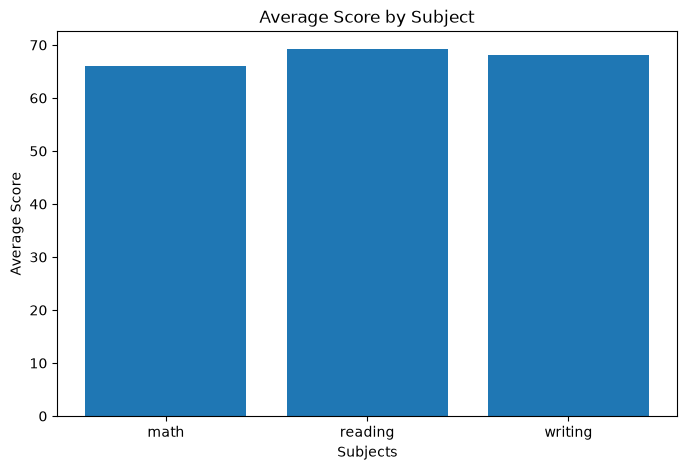

In [36]:
plt.figure(figsize=(8,5))

plt.bar(subject_average.index,
        subject_average.values)

plt.title("Average Score by Subject")

plt.xlabel("Subjects")

plt.ylabel("Average Score")

plt.show()

In [40]:
plt.savefig("../charts/bar_chart.png")

<Figure size 640x480 with 0 Axes>

# HISTOGRAM

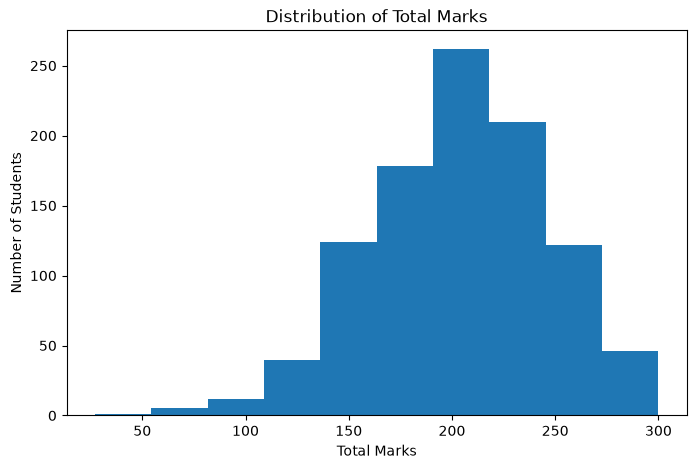

In [37]:
plt.figure(figsize=(8,5))

plt.hist(df["Total"], bins=10)

plt.title("Distribution of Total Marks")

plt.xlabel("Total Marks")

plt.ylabel("Number of Students")

plt.show()

In [41]:
plt.savefig("../charts/histogram.png")

<Figure size 640x480 with 0 Axes>

# PIE CHART

In [38]:
grade_count = df["Grade"].value_counts()

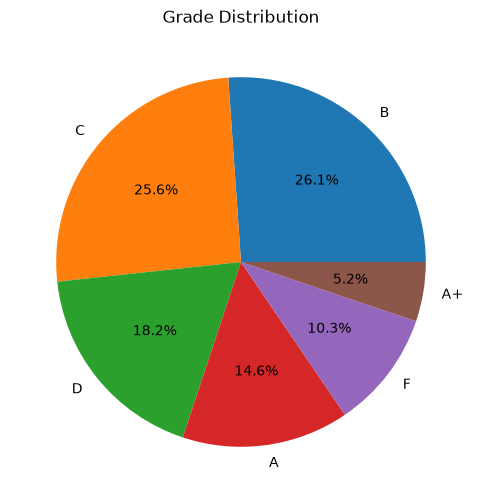

In [39]:
plt.figure(figsize=(6,6))

plt.pie(
    grade_count,
    labels=grade_count.index,
    autopct="%1.1f%%"
)

plt.title("Grade Distribution")

plt.show()

In [42]:
plt.savefig("../charts/pie_chart.png")

<Figure size 640x480 with 0 Axes>

In [43]:
df.to_csv("../outputs/student_analysis.csv", index=False)